In [1]:
# import classy module
import classy
print (classy.__version__)

v3.1.1


In [2]:
# import classy module
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
LambdaCDM.set({'output':'mPk','P_k_max_1/Mpc':200,'z_max_pk':3.5})
LambdaCDM.set({'non_linear':'oneloopPT'})
LambdaCDM.set({'has_rsd':'yes'})
LambdaCDM.set({'eft_compute_loop_matrices':'yes'})
LambdaCDM.set({'eft_enable_mu_approximation':'yes'})
LambdaCDM.set({'eft_write_loop_matrices':'no'})
LambdaCDM.set({'eft_direct_integration':'no'})
LambdaCDM.set({'fourier_verbose': 3, 'eft_verbose': 3})
# run class
LambdaCDM.compute()

Computing linear Fourier spectra. 
Computing nowiggle Fourier spectra.
Could not open file for nowiggle powerspectrum output.
 -> sigma8=0.825009 for total matter (computed till k = 329.866 h/Mpc)
Computing one-loop power spectrum including EFT terms (proper credits to Azadeh et al. will have to be added here)
compute_loop_matrices = 1 
compute mu approximation = 1 
Generated 300 sample points for the linear power spectrum with
a base point density of 9.9 and of 79.0 per decade at the feature. 
Generated 300 sample points for the linear power spectrum with
a base point density of 9.2 and of 73.9 per decade at the feature. 
Generated 400 sample points for the linear power spectrum with
a base point density of 13.6 and of 109.1 per decade at the feature. 
Generated 200 sample points for the linear power spectrum with
a base point density of 16.3 and of 130.1 per decade at the feature. 
Could not insert loop matrices from external storage for index = 0: 
 => Nothing is stored in pext = 0x

In [4]:
# Choose parameters relevant for P_oneloop
#
# vector of z values
z = np.array([0.,1.],'float64')
z_size = z.shape[0]
# number of mu values from 0 to 1
mu_size = 3
# number of k values, k_min and k_max in 1/Mpc
k_size = 100
kmin=0.001071519
kmax=0.9332543
# parameters of oneloop model
biases = np.tile(np.array([1,-0.5,0.3,0.8], dtype='float64'), (z_size, 1))
counterterms = np.tile(np.array([-10,20,20,20,0,0,0], dtype='float64'), (z_size, 1))

In [5]:
# Put the input in the right format and call eft_job_powerspectrum_wedges_grid()
#
# array z[index_z]
# z_size = len(z)
# #
# # create array mu[index_z + z_size*index_mu]
# muvec = np.zeros(mu_size,'float64')
# for index_mu in range(mu_size):
#     muvec[index_mu]= index_mu/(mu_size-1.)
# mu = np.zeros(z_size*mu_size,'float64')    
# for index_z in range(z_size):
#     for index_mu in range(mu_size):
#         mu[index_z + z_size*index_mu] = muvec[index_mu]
# #
# # create array k[index_z + z_size*(index_mu + mu_size*index_k)]
# kvec = np.zeros(k_size,'float64')
# for index_k in range(k_size):
#     kvec[index_k]=kmin*np.exp(index_k/(k_size-1.)*np.log(kmax/kmin))
# k = np.zeros(z_size*mu_size*k_size,'float64')        
# for index_k in range(k_size):
#     for index_z in range(z_size):
#         for index_mu in range(mu_size):
#             k[index_z + z_size*(index_mu + mu_size*index_k)] = kvec[index_k]
# #    
# pkmuz = LambdaCDM.eft_job_powerspectrum_wedges_grid(mu,
#                                                     k,
#                                                     z,
#                                                     mu_size,
#                                                     k_size,
#                                                     z_size,
#                                                     'Pdd_hh_rsd',
#                                                     biases,
#                                                     counterterms,
#                                                     R2,
#                                                     cs2,
#                                                     has_rsd)

In [6]:
mu = np.tile(np.linspace(0., 1., mu_size, endpoint=True, dtype='float64'), (z_size, 1))
k = np.tile(np.geomspace(kmin, kmax, k_size, endpoint=True, dtype='float64'), (z_size, mu_size, 1))
print(mu.shape)
print(k.shape)

pkmuz = LambdaCDM.eft_pkmu_rsd_grid(mu, k, z, biases, counterterms, 'Pdd_hh_rsd')

(2, 3)
(2, 3, 100)
index_pk_type = 0, index_tracer = 0, index_mu = 0: Performed Spline Fourier with bias -0.30 and relative power loss of 1.069e-09 at frequencies higher than 3.755e+01 
                                                      Fourier coefficients are bounded by 5.930e+05 / frequency^3 
index_pk_type = 0, index_tracer = 1, index_mu = 0: Performed Spline Fourier with bias -1.55 and relative power loss of 2.503e-07 at frequencies higher than 3.527e+01 
                                                      Fourier coefficients are bounded by 7.375e+04 / frequency^3 
index_pk_type = 1, index_tracer = 0, index_mu = 0: Performed Spline Fourier with bias -0.30 and relative power loss of 3.435e-12 at frequencies higher than 3.755e+01 
                                                      Fourier coefficients are bounded by 3.254e+04 / frequency^3 
index_pk_type = 1, index_tracer = 1, index_mu = 0: Performed Spline Fourier with bias -1.55 and relative power loss of 6.530e-13 at fre

In [7]:
?LambdaCDM.eft_pkmu_rsd_grid

Signature: LambdaCDM.eft_pkmu_rsd_grid(mu, k, z, biases, counterterms, pkmu_type)
Docstring:
eft_job_powerspectrum_wedges_grid(mu, k, z, z_size, mu_size, k_size, pkmu_type, biases, counterterms)

Returns the oneloop power spectrum P_oneloop(k,mu,z)

Input parameters
----------------
mu      : numpy array of mu values, indexed as mu[index_z, index_mu]
k       : numpy array of k values, indexed as k[index_z, index_mu, index_k]
z       : numpy array of z values, indexed as z[index_z]
pkmu_type: input: one of 'Pdd_mm_rsd', 'Pdd_hh_rsd'
biases : input: numpy array of biases [b1,b2,bG2,btd]
counterterms : input: numpy array of counterterms [c00,c10,c22,c32,c20,c30,c42]

Returns:
--------
out_pkmuz : a numpy array of P(k,mu,z) indexed as out_pkmuz[index_z, index_mu, index_k]
Type:      method

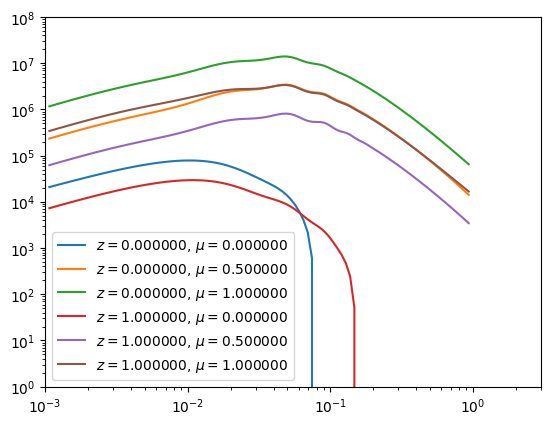

In [8]:
# plot the result
for index_z in range(z_size):
    for index_mu in range(mu_size):
        plt.loglog(k[index_z, index_mu],pkmuz[index_z, index_mu],label=r"$z=%f$, $\mu=%f$"%(z[index_z],mu[index_z, index_mu]))
plt.xlim([1.e-3,3.]) 
plt.ylim([1.e0,1e8]) 
plt.legend()